In [1]:
import librosa  # ty: ignore
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = 'svg'
plt.rcdefaults()  # ty: ignore

In [2]:
SAMPLE_AUDIO_PATH = "../data/sample_audio/sample_011_figure_source.wav"

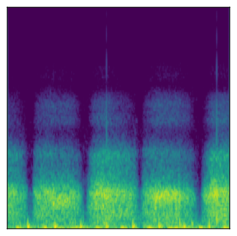

In [3]:
sample_waveform, sample_rate = librosa.load(SAMPLE_AUDIO_PATH, dtype=np.float32)

signal = librosa.resample(sample_waveform, orig_sr=sample_rate, target_sr=16000)

mel_spec = librosa.feature.melspectrogram(
    y=signal, sr=16000, n_mels=128, n_fft=1024, hop_length=160, fmin=0, fmax=8000
)
log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
log_mel_spec = (log_mel_spec - log_mel_spec.mean()) / (log_mel_spec.std() + 1e-8)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(log_mel_spec, cmap="viridis", aspect="auto", alpha=1, origin="lower")  # ty: ignore
ax.set_xticks([])
ax.set_yticks([])
plt.show()